In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Set seaborn theme for cleaner visuals
sns.set(style="whitegrid")

# Number of rows
n_rows = 5000

# Define Rift Valley locations
rift_valley_locations = [
    "Nakuru", "Eldoret", "Kitale", "Naivasha", "Narok", "Kericho", "Kapsabet",
    "Kabarnet", "Iten", "Nyahururu", "Lake Nakuru", "Lake Naivasha", "Lake Baringo",
    "Lake Bogoria", "Lake Elementaita", "Kerio Valley", "Mau Escarpment", "Tugen Hills",
    "Cherangani Hills", "Bomet"
]

# Generate data
years = np.random.randint(2010, 2024, n_rows)
locations = np.random.choice(rift_valley_locations, n_rows)
rainfall = np.random.uniform(300, 1200, n_rows)
temperature = np.random.uniform(15, 28, n_rows)
humidity = np.random.uniform(50, 90, n_rows)
soil_moisture = np.random.uniform(10, 40, n_rows)
soil_ph = np.random.uniform(5.0, 7.5, n_rows)
organic_carbon = np.random.uniform(0.5, 3.0, n_rows)
fertilizer = np.random.uniform(50, 200, n_rows)
planting_date = np.random.randint(60, 120, n_rows)
prev_yield = np.random.uniform(1.5, 5.0, n_rows)
market_price = np.random.uniform(2000, 5000, n_rows)
days_to_harvest = np.random.randint(90, 150, n_rows)

# Simulate labour cost (depends on yield and season)
labour_base = 500 + 100 * prev_yield + 50 * (planting_date / 120)
labour_noise = np.random.normal(0, 100, n_rows)
labour_cost = np.clip(labour_base + labour_noise, 500, 2000)

# Simulate storage loss (depends on humidity)
storage_base = 5 + 0.3 * humidity
storage_noise = np.random.normal(0, 5, n_rows)
storage_loss = np.clip(storage_base + storage_noise, 5, 30)

# Simulate yield
yield_base = (
    0.002 * rainfall + 0.1 * soil_moisture + 0.05 * organic_carbon + 
    0.01 * fertilizer - 0.05 * temperature
) * 0.8
yield_noise = np.random.normal(0, 0.5, n_rows)
maize_yield = np.clip(yield_base + yield_noise, 1.5, 6.0)

# Create DataFrame
data = pd.DataFrame({
    'Year': years, 'Location': locations, 'Rainfall (mm)': rainfall, 
    'Avg_Temperature (°C)': temperature, 'Humidity (%)': humidity, 
    'Soil_Moisture (%)': soil_moisture, 'Soil_pH': soil_ph, 
    'Organic_Carbon (%)': organic_carbon, 'Fertilizer (kg/ha)': fertilizer, 
    'Planting_Date': planting_date, 'Prev_Yield (tons/ha)': prev_yield, 
    'Market_Price (KES/ton)': market_price, 'Days_to_Harvest': days_to_harvest, 
    'Labour_Cost (KES/ha)': labour_cost, 'Storage_Loss (%)': storage_loss, 
    'Yield (tons/ha)': maize_yield
})

# Save to CSV
data.to_csv('../data/raw/maize_yield_dataset_5000_locations.csv', index=False)
print("Dataset with 5000 rows and Rift Valley locations saved as 'maize_yield_dataset_5000_locations.csv'")

Dataset with 5000 rows and Rift Valley locations saved as 'maize_yield_dataset_5000_locations.csv'


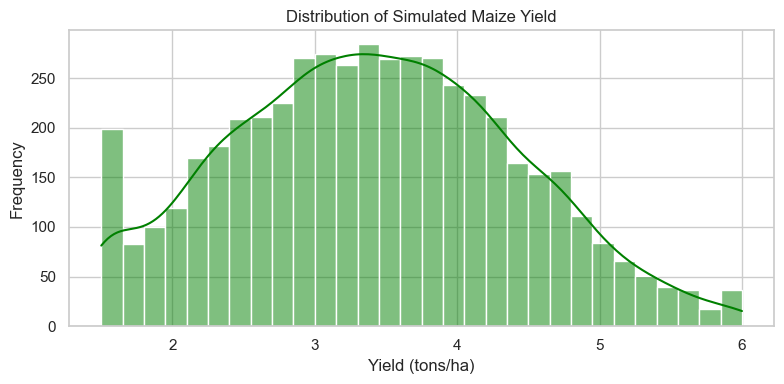

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(data['Yield (tons/ha)'], bins=30, kde=True, color='green')
plt.title('Distribution of Simulated Maize Yield')
plt.xlabel('Yield (tons/ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


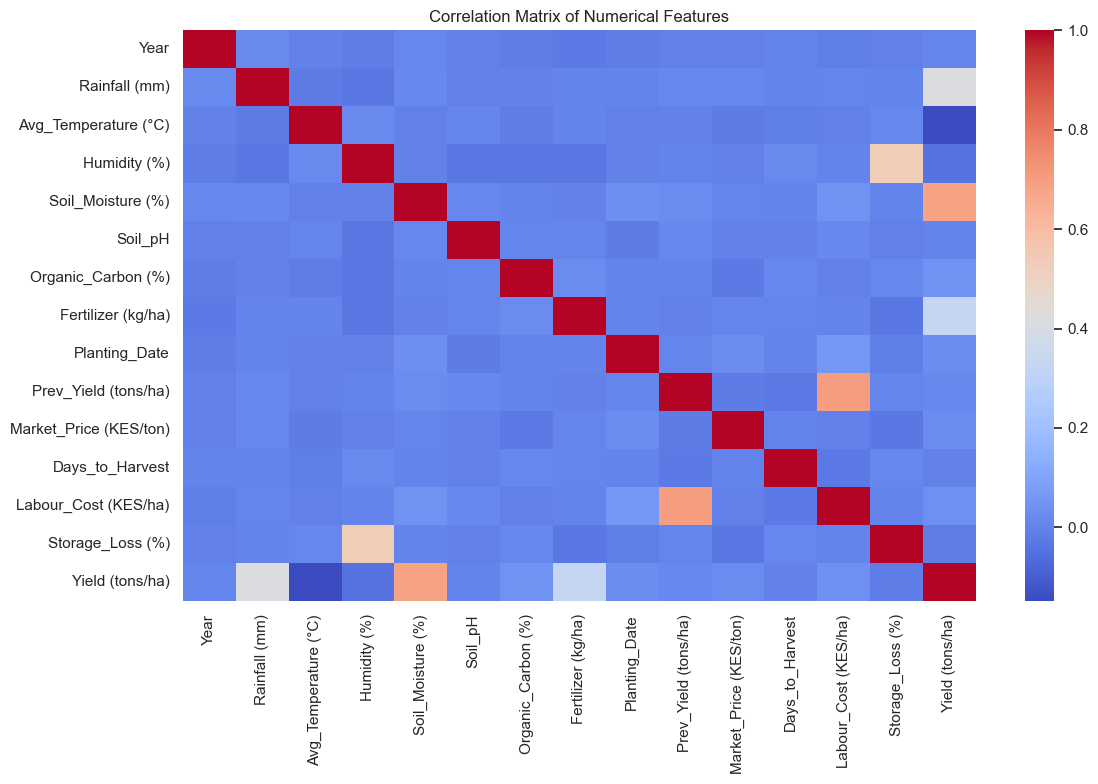

In [4]:
plt.figure(figsize=(12, 8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


In [7]:
data = pd.read_csv('../data/raw/maize_yield_dataset_5000_locations.csv')

# Pre-process data
# One-hot encode 'Location'
data = pd.get_dummies(data, columns=['Location'], drop_first=True)

In [15]:
# Define features and target
X = data.drop(['Yield (tons/ha)', 'Market_Price (KES/ton)', 'Days_to_Harvest', 
               'Labour_Cost (KES/ha)', 'Storage_Loss (%)'], axis=1)
y = data['Yield (tons/ha)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
# Train Random Forest model with hyperparameter tuning
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 300, 500]},
             scoring='neg_mean_squared_error')

In [10]:
# Best model
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}


C:\Users\moses\AppData\Local\Temp\ipykernel_17184\2200636550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15], palette="viridis")


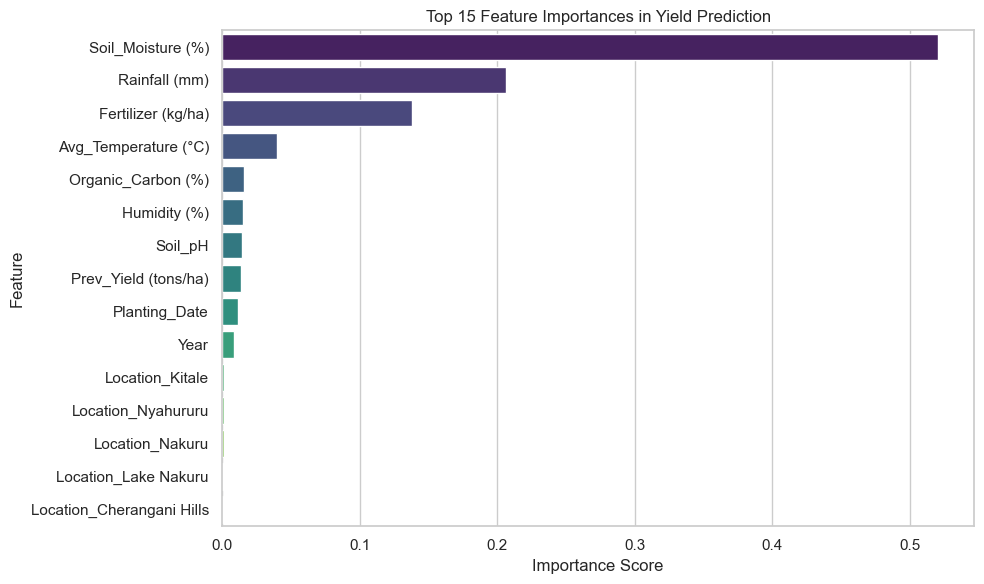

In [11]:
importances = best_rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15], palette="viridis")
plt.title("Top 15 Feature Importances in Yield Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


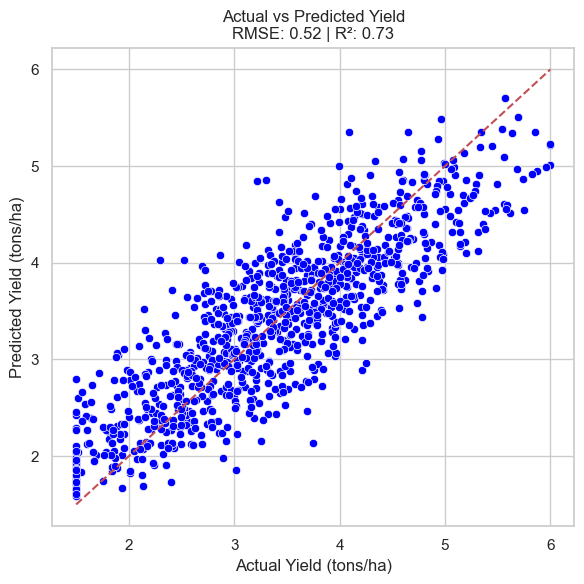

In [22]:
y_pred = best_rf.predict(X_test) 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Yield (tons/ha)")
plt.ylabel("Predicted Yield (tons/ha)")
plt.title(f"Actual vs Predicted Yield\nRMSE: {rmse:.2f} | R²: {r2:.2f}")
plt.tight_layout()
plt.show()



In [21]:
plt.savefig('actual_vs_predicted_yield.png')


<Figure size 640x480 with 0 Axes>

In [23]:
# Evaluate model
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f} tons/ha")
print(f"R²: {r2:.2f}")

RMSE: 0.52 tons/ha
R²: 0.73


In [27]:
# Save model
with open('rf_yield_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)